# FWCP Demo

This notebook demonstrates the unified `fwcp.py` module. It covers the main estimator families:

- Bunching estimator
- Same-sample symmetry estimator
- Holden and Wulfsberg (2009) frequency and integration estimators
- Rule-of-thumb estimator


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fwcp import (
    BunchingEstimator,
    SymmetricEstimator,
    HoldenWulfsberg2009Estimator,
    RuleOfThumbEstimator,
)

rng = np.random.default_rng(7)

# Simulated wage growth with a mild zero-growth spike.
actual = np.concatenate([
    rng.normal(loc=0.03, scale=0.11, size=2500),
    rng.uniform(-0.01, 0.01, size=180),
])

# Reference sample for the HW2009 estimator.
reference = rng.laplace(loc=0.05, scale=0.18, size=3500)

xlim = (-0.5, 0.8)
bin_width = 0.02


In [2]:
bunch = BunchingEstimator(bin_width=bin_width, xlim=xlim, degree=14, alpha=1e-3).fit(actual)
bunch.summary()

FWCPResult(absolute=3.398979055429781, relative=0.5032742468812712, method='bunching')

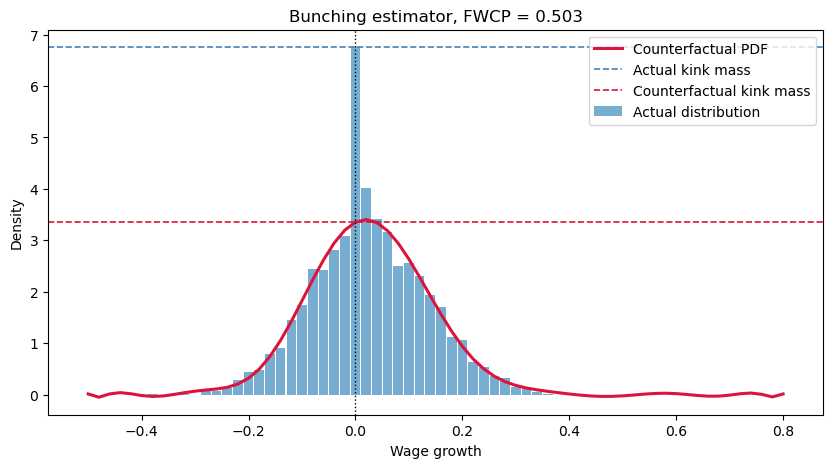

In [3]:
plot_b = bunch.plotdata()

plt.figure(figsize=(10, 5))
plt.bar(plot_b['x'], plot_b['y_actual'], width=plot_b['bin_width'] * 0.9, alpha=0.6, label='Actual distribution')
plt.plot(plot_b['x'], plot_b['y_notional'], color='crimson', lw=2.2, label='Counterfactual PDF')
plt.axhline(plot_b['kink_mass_actual'], color='steelblue', ls='--', lw=1.2, label='Actual kink mass')
plt.axhline(plot_b['kink_mass_notional'], color='crimson', ls='--', lw=1.2, label='Counterfactual kink mass')
plt.axvline(plot_b['kink_point'], color='black', ls=':', lw=1)
plt.title(f'Bunching estimator, FWCP = {bunch.fwcp_relative:.3f}')
plt.xlabel('Wage growth')
plt.ylabel('Density')
plt.legend()
plt.show()


In [4]:
sym = SymmetricEstimator(
    bin_width=bin_width,
    xlim=xlim,
    degree=14,
    alpha=1e-3,
    symmetry_type='median',
    centering=True,
).fit(actual)

print('Symmetric FWCP, unweighted integral:', round(sym.fwcp_absolute, 4))
print('Symmetric FWCP, weighted integral:', round(sym.fwcp_relative, 4))
print('Center used for symmetry:', round(sym.datMid, 4))


Symmetric FWCP, unweighted integral: 0.0262
Symmetric FWCP, weighted integral: 0.0042
Center used for symmetry: 0.0325


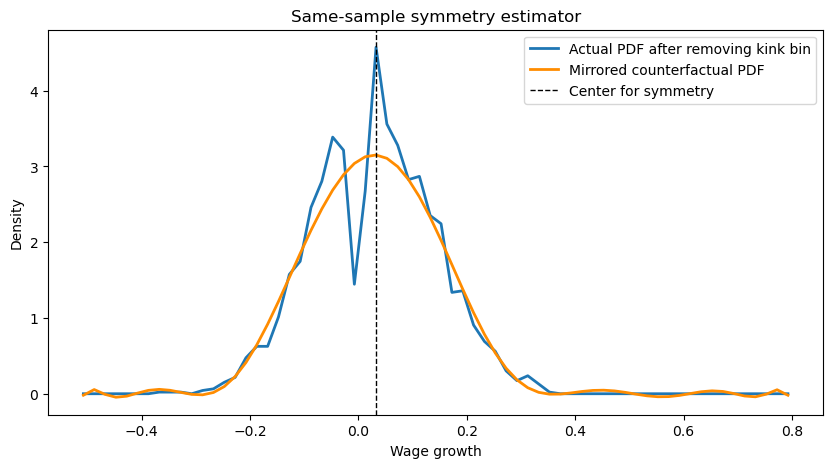

In [5]:
plot_s = sym.plotdata()

plt.figure(figsize=(10, 5))
plt.plot(plot_s['x_original'], plot_s['y_actual'], lw=2, label='Actual PDF after removing kink bin')
plt.plot(plot_s['x_original'], plot_s['y_notional'], lw=2, color='darkorange', label='Mirrored counterfactual PDF')
plt.axvline(plot_s['center'], color='black', ls='--', lw=1, label='Center for symmetry')
plt.title('Same-sample symmetry estimator')
plt.xlabel('Wage growth')
plt.ylabel('Density')
plt.legend()
plt.show()


In [6]:
hw = HoldenWulfsberg2009Estimator(reference).fit(actual)

print('HW2009 frequency FWCP:', round(hw.fwcp_frequency(), 4))
print('HW2009 unweighted integral FWCP:', round(hw.fwcp_integral(weighted=False), 4))
print('HW2009 weighted integral FWCP:', round(hw.fwcp_integral(weighted=True), 4))


HW2009 frequency FWCP: 0.0405
HW2009 unweighted integral FWCP: 0.0129
HW2009 weighted integral FWCP: 0.0109


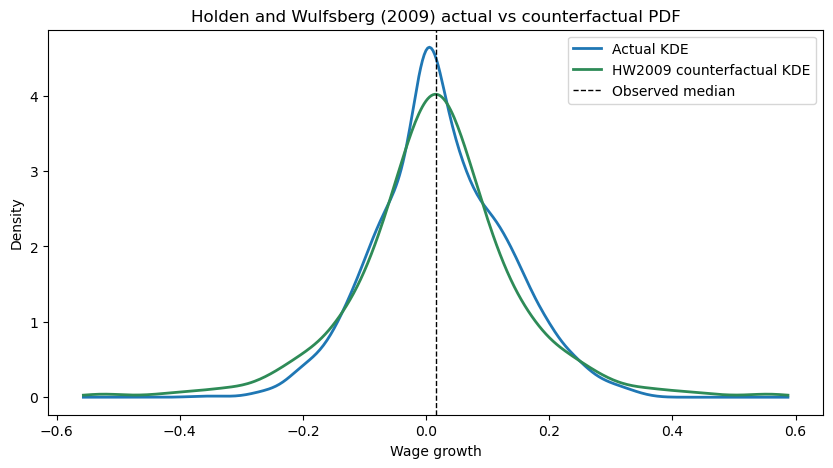

In [7]:
plot_h = hw.plotdata()

plt.figure(figsize=(10, 5))
plt.plot(plot_h['x'], plot_h['y_actual'], lw=2, label='Actual KDE')
plt.plot(plot_h['x'], plot_h['y_notional'], lw=2, color='seagreen', label='HW2009 counterfactual KDE')
plt.axvline(plot_h['center'], color='black', ls='--', lw=1, label='Observed median')
plt.title('Holden and Wulfsberg (2009) actual vs counterfactual PDF')
plt.xlabel('Wage growth')
plt.ylabel('Density')
plt.legend()
plt.show()


In [8]:
rule = RuleOfThumbEstimator().fit(actual)
print('Rule-of-thumb FWCP:', round(rule.fwcp_relative, 4))


Rule-of-thumb FWCP: 0.1776
